In [ ]:
import requests
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import time
import warnings
warnings.filterwarnings('ignore')

# Core ML Libraries
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV,
    cross_val_score, validation_curve, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, precision_score, recall_score,
    accuracy_score, log_loss, brier_score_loss
)
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical tests
from scipy import stats
from scipy.stats import chi2_contingency, mannwhitneyu, ttest_ind

# Resource monitoring
import psutil
import gc

# XGBoost
import xgboost as xgb

# Global variables to store results across functions
results = {}
best_models = {}
tuning_results = {}
evaluation_results = {}
optimal_thresholds = {}
calibration_results = {}
fairness_results = {}

In [ ]:
def get_date_range(months_back=12):
    """Generate date range for data collection"""
    base_date = datetime.today().replace(day=1)
    dates = [(base_date - timedelta(days=30 * i)).strftime('%Y-%m')
             for i in range(1, months_back + 1)]
    return dates

In [ ]:
def collect_data(latitude, longitude, month, max_retries=3):
    base_url = "https://data.police.uk/api/crimes-street/all-crime"
    url = f"{base_url}?lat={latitude}&lng={longitude}&date={month}"

    for attempt in range(max_retries):
        try:
            response = requests.get(url, timeout=30)
            if response.status_code == 200:
                data = response.json()
                print(f"Successfully collected {len(data)} records for {month}")
                return data
            else:
                print(f"HTTP {response.status_code} for {month}, attempt {attempt + 1}")

        except requests.exceptions.RequestException as e:
            print(f"⚠ Request failed for {month}, attempt {attempt + 1}: {e}")

        if attempt < max_retries - 1:
            time.sleep(2 ** attempt)  # Exponential backoff

    print(f"Failed to collect data for {month} after {max_retries} attempts")
    return []

In [ ]:
def collect_all_crime_data(latitude=51.4545, longitude=-2.5879):
    dates = get_date_range()
    all_data = []

    print(f"Collecting crime data for {len(dates)} months")
    print("Date range:", dates[0], "to", dates[-1])

    for i, month in enumerate(dates, 1):
        print(f"[{i}/{len(dates)}] Processing {month}...")
        monthly_data = collect_data(latitude, longitude, month)
        all_data.extend(monthly_data)
        time.sleep(1)  # Rate limiting

    return all_data

In [ ]:
def analyze_data(df):

    print(f"Dataset shape: {df.shape}")
    print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

    # Missing values analysis
    missing_analysis = pd.DataFrame({
        'Column': df.columns,
        'Missing_Count': df.isnull().sum(),
        'Missing_Percentage': (df.isnull().sum() / len(df)) * 100,
        'Data_Type': df.dtypes
    })
    missing_analysis = missing_analysis[missing_analysis['Missing_Count'] > 0]

    if not missing_analysis.empty:
        print("\nMissing Values Analysis:")
        print(missing_analysis.to_string(index=False))
    else:
        print("\n✓ No missing values detected")

    # Duplicate analysis
    unhashable_cols = [col for col in df.columns if df[col].apply(lambda x: isinstance(x, (dict, list))).any()]
    if unhashable_cols:
        print(f"⚠ Skipping unhashable columns for duplicate check: {unhashable_cols}")
        df_safe = df.drop(columns=unhashable_cols)
        duplicates = df_safe.duplicated().sum()
        print(f"\nDuplicate records: {duplicates} ({duplicates / len(df) * 100:.2f}%)")
    else:
        duplicates = df.duplicated().sum()
        print(f"\nDuplicate records: {duplicates} ({duplicates / len(df) * 100:.2f}%)")

    return missing_analysis

In [ ]:
def target_variable(df):

    violent_crime_categories = [
        'criminal-damage-arson',
        'possession-of-weapons',
        'public-order',
        'robbery',
        'violent-crime'
    ]

    # Create binary target
    df['is_violent'] = df['category'].isin(violent_crime_categories).astype(int)

    # Analyze class distribution
    class_dist = df['is_violent'].value_counts()
    non_violent = class_dist.get(0, 0)
    violent = class_dist.get(1, 0)

    print("Class Distribution:")
    print(f"Non-violent crimes (0): {non_violent} ({non_violent / len(df) * 100:.1f}%)")
    print(f"Violent crimes (1): {violent} ({violent / len(df) * 100:.1f}%)")

    # Calculate imbalance ratio (only if violent > 0)
    if violent > 0:
        imbalance_ratio = non_violent / violent
        print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")
    else:
        print("⚠ No violent crimes found. Imbalance ratio undefined.")

    return df

In [ ]:
def feature_engineering(df_train, df_test=None):

    # If no test set provided, we're doing initial exploration
    if df_test is None:
        df_test = df_train.copy()
        fitting_mode = True
    else:
        fitting_mode = False

    # Initialize encoders dictionary to store fitted encoders
    encoders = {}

    # Process training data and fit encoders
    df_train_processed = df_train.copy()

    # Temporal features
    df_train_processed['month'] = pd.to_datetime(df_train_processed['month'], errors='coerce').dt.month
    df_train_processed = df_train_processed.dropna(subset=['month'])

    df_train_processed['season'] = pd.cut(df_train_processed['month'], bins=[0, 3, 6, 9, 12],
                         labels=['Winter', 'Spring', 'Summer', 'Autumn'],
                         include_lowest=True)

    df_train_processed['is_weekend'] = 0  # Optional placeholder

    # Location-based features - FIT on training data
    location_encoder = LabelEncoder()
    df_train_processed['location_type_encoded'] = location_encoder.fit_transform(
        df_train_processed['location_type'].fillna('Unknown')
    )
    encoders['location_type'] = location_encoder

    # Outcome status features
    df_train_processed['has_outcome'] = (~df_train_processed['outcome_status'].isna()).astype(int)

    # Extract coordinates if available
    if 'location' in df_train_processed.columns and df_train_processed['location'].notna().any():
        try:
            coords = df_train_processed['location'].apply(lambda x: eval(x) if pd.notna(x) else {'latitude': None, 'longitude': None})
            df_train_processed['latitude'] = coords.apply(lambda x: x.get('latitude') if isinstance(x, dict) else None)
            df_train_processed['longitude'] = coords.apply(lambda x: x.get('longitude') if isinstance(x, dict) else None)
        except:
            print("⚠ Could not extract coordinates from location data")

    # Process test data using fitted encoders (if different from train)
    if not fitting_mode:
        df_test_processed = df_test.copy()

        # Temporal features
        df_test_processed['month'] = pd.to_datetime(df_test_processed['month'], errors='coerce').dt.month
        df_test_processed = df_test_processed.dropna(subset=['month'])

        df_test_processed['season'] = pd.cut(df_test_processed['month'], bins=[0, 3, 6, 9, 12],
                             labels=['Winter', 'Spring', 'Summer', 'Autumn'],
                             include_lowest=True)

        df_test_processed['is_weekend'] = 0

        # Apply fitted encoder to test data - TRANSFORM only
        test_location_types = df_test_processed['location_type'].fillna('Unknown')

        # Handle unseen categories in test set
        known_categories = set(encoders['location_type'].classes_)
        test_location_types = test_location_types.apply(
            lambda x: x if x in known_categories else 'Unknown'
        )

        df_test_processed['location_type_encoded'] = encoders['location_type'].transform(test_location_types)

        # Outcome status features
        df_test_processed['has_outcome'] = (~df_test_processed['outcome_status'].isna()).astype(int)

        # Extract coordinates if available
        if 'location' in df_test_processed.columns and df_test_processed['location'].notna().any():
            try:
                coords = df_test_processed['location'].apply(lambda x: eval(x) if pd.notna(x) else {'latitude': None, 'longitude': None})
                df_test_processed['latitude'] = coords.apply(lambda x: x.get('latitude') if isinstance(x, dict) else None)
                df_test_processed['longitude'] = coords.apply(lambda x: x.get('longitude') if isinstance(x, dict) else None)
            except:
                print("Could not extract coordinates from location data")

        print("Feature engineering completed for both train and test sets")
        return df_train_processed, df_test_processed, encoders
    else:
        print("Feature engineering completed for exploration")
        return df_train_processed, encoders

In [ ]:
def model_features(df_train, df_test=None, encoders=None):

    # If no test set provided, we're doing initial exploration
    if df_test is None:
        df_test = df_train.copy()
        fitting_mode = True
    else:
        fitting_mode = False

    # Select features for modeling
    feature_columns = [
        'month', 'location_type_encoded', 'has_outcome', 'is_weekend'
    ]

    # Process training data
    available_features = [col for col in feature_columns if col in df_train.columns]
    categorical_features = ['season'] if 'season' in df_train.columns else []

    if categorical_features:
        df_train_encoded = pd.get_dummies(df_train, columns=categorical_features, prefix=categorical_features)
        # Get new categorical columns
        new_categorical_cols = [col for col in df_train_encoded.columns if any(cat in col for cat in categorical_features)]
        available_features.extend(new_categorical_cols)
    else:
        df_train_encoded = df_train.copy()

    # Final feature matrix for training
    X_train = df_train_encoded[available_features].copy()
    y_train = df_train_encoded['is_violent'].copy()

    # Handle missing values in training data
    X_train = X_train.fillna(X_train.median(numeric_only=True))
    X_train = X_train.fillna(0)  # For non-numeric columns

    if not fitting_mode:
        # Process test data using the same transformations
        if categorical_features:
            df_test_encoded = pd.get_dummies(df_test, columns=categorical_features, prefix=categorical_features)

            # Ensure test set has same columns as training set
            missing_cols = set(df_train_encoded.columns) - set(df_test_encoded.columns)
            for col in missing_cols:
                if col in available_features:
                    df_test_encoded[col] = 0

            # Remove extra columns in test set that weren't in training
            extra_cols = set(df_test_encoded.columns) - set(df_train_encoded.columns)
            for col in extra_cols:
                if col.startswith(tuple(categorical_features)):
                    df_test_encoded = df_test_encoded.drop(columns=[col])
        else:
            df_test_encoded = df_test.copy()

        # Final feature matrix for testing
        X_test = df_test_encoded[available_features].copy()
        y_test = df_test_encoded['is_violent'].copy()

        # Handle missing values in test data using training statistics
        for col in X_test.select_dtypes(include=[np.number]).columns:
            if col in X_train.columns:
                X_test[col] = X_test[col].fillna(X_train[col].median())
        X_test = X_test.fillna(0)  # For non-numeric columns

        print(f"✓ Training feature matrix: {X_train.shape}")
        print(f"✓ Test feature matrix: {X_test.shape}")
        print(f"Features: {list(X_train.columns)}")
        print(f"Training target distribution: {y_train.value_counts().to_dict()}")
        print(f"Test target distribution: {y_test.value_counts().to_dict()}")

        return X_train, X_test, y_train, y_test, df_train_encoded, df_test_encoded
    else:
        print(f"✓ Exploration feature matrix: {X_train.shape}")
        print(f"Features: {list(X_train.columns)}")
        print(f"Target distribution: {y_train.value_counts().to_dict()}")

        return X_train, y_train, df_train_encoded

In [ ]:
def models(random_state=14):

    model_configs = {
        'Logistic_Regression': {
            'model': LogisticRegression(random_state=random_state, max_iter=1000),
            'param_grid': {
                'C': [0.001, 0.01, 0.1, 1, 10, 100],
                'penalty': ['l1', 'l2', 'elasticnet'],
                'solver': ['liblinear', 'saga'],
                'class_weight': [None, 'balanced']
            },
            'search_type': 'grid'
        },

        'XGBoost': {
            'model': xgb.XGBClassifier(
                random_state=random_state,
                eval_metric='logloss',
                verbosity=0
            ),
            'param_grid': {
                'n_estimators': [100, 200, 300],
                'max_depth': [3, 4, 5, 6],
                'learning_rate': [0.01, 0.1, 0.2],
                'subsample': [0.8, 0.9, 1.0],
                'colsample_bytree': [0.8, 0.9, 1.0],
                'scale_pos_weight': [1, 2, 3]  # Handle class imbalance
            },
            'search_type': 'random'
        },

        'Neural_Network': {
            'model': MLPClassifier(
                random_state=random_state,
                max_iter=1000,
                early_stopping=True,
                validation_fraction=0.1
            ),
            'param_grid': {
                'hidden_layer_sizes': [(50,), (100,), (50, 25), (100, 50)],
                'activation': ['relu', 'tanh'],
                'alpha': [0.0001, 0.001, 0.01],
                'learning_rate': ['constant', 'adaptive'],
                'solver': ['adam', 'lbfgs']
            },
            'search_type': 'random'
        }
    }

    print("✓ Model configurations prepared:")
    for name, config in model_configs.items():
        param_combinations = np.prod([len(v) if isinstance(v, list) else 1
                                    for v in config['param_grid'].values()])
        print(f"  - {name}: {param_combinations} parameter combinations")

    return model_configs


In [ ]:
def optimize_hyperparameters(model_configs, X_train, y_train, random_state=14):

    global best_models, tuning_results
    best_models = {}
    tuning_results = {}

    # Setup cross-validation
    cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)

    for model_name, config in model_configs.items():
        print(f"\nOptimizing {model_name}...")
        start_time = time.time()

        # Choose search strategy
        if config['search_type'] == 'grid':
            search = GridSearchCV(
                config['model'],
                config['param_grid'],
                cv=cv_strategy,
                scoring='f1',
                n_jobs=-1,
                verbose=0
            )
        else:
            search = RandomizedSearchCV(
                config['model'],
                config['param_grid'],
                n_iter=50,
                cv=cv_strategy,
                scoring='f1',
                n_jobs=-1,
                random_state=random_state,
                verbose=0
            )

        # Fit the search
        search.fit(X_train, y_train)

        # Store results
        best_models[model_name] = search.best_estimator_
        tuning_results[model_name] = {
            'best_params': search.best_params_,
            'best_score': search.best_score_,
            'cv_results': search.cv_results_,
            'optimization_time': time.time() - start_time
        }

        print(f"✓ Best CV F1-score: {search.best_score_:.4f}")
        print(f"✓ Best parameters: {search.best_params_}")
        print(f"✓ Optimization time: {time.time() - start_time:.2f} seconds")

    return best_models, tuning_results

In [ ]:
def cross_validation(models, X, y, cv_folds=10, random_state=14):
    """Perform robust cross-validation with multiple metrics"""
    print("\n12. ROBUST CROSS-VALIDATION ANALYSIS")
    print("-" * 50)

    # Setup cross-validation
    cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=random_state)

    # Metrics to evaluate
    scoring_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

    cv_results = {}

    for model_name, model in models.items():
        print(f"\nCross-validating {model_name}...")

        model_cv_results = {}

        for metric in scoring_metrics:
            try:
                scores = cross_val_score(model, X, y, cv=cv_strategy,
                                       scoring=metric, n_jobs=-1)

                model_cv_results[metric] = {
                    'mean': scores.mean(),
                    'std': scores.std(),
                    'scores': scores,
                    'ci_lower': scores.mean() - 1.96 * scores.std() / np.sqrt(cv_folds),
                    'ci_upper': scores.mean() + 1.96 * scores.std() / np.sqrt(cv_folds)
                }

                print(f"  {metric.upper()}: {scores.mean():.4f} ± {scores.std():.4f}")

            except Exception as e:
                print(f"  ⚠ Failed to compute {metric} for {model_name}: {e}")

        cv_results[model_name] = model_cv_results

    return cv_results

In [ ]:
def analyze_model(cv_results):
    print("\n13. MODEL STABILITY ANALYSIS")
    print("-" * 50)

    stability_analysis = {}

    for model_name, results in cv_results.items():
        if 'f1' in results:
            f1_scores = results['f1']['scores']

            stability_metrics = {
                'coefficient_of_variation': results['f1']['std'] / results['f1']['mean'],
                'range': f1_scores.max() - f1_scores.min(),
                'iqr': np.percentile(f1_scores, 75) - np.percentile(f1_scores, 25),
                'stability_score': 1 - (results['f1']['std'] / results['f1']['mean'])  # Higher is more stable
            }

            stability_analysis[model_name] = stability_metrics

            print(f"\n{model_name} Stability Metrics:")
            print(f"  Coefficient of Variation: {stability_metrics['coefficient_of_variation']:.4f}")
            print(f"  Score Range: {stability_metrics['range']:.4f}")
            print(f"  Stability Score: {stability_metrics['stability_score']:.4f}")

    # Find most stable model
    if stability_analysis:
        most_stable = max(stability_analysis.items(),
                         key=lambda x: x[1]['stability_score'])

        print(f"\nMost Stable Model: {most_stable[0]}")
        print(f"   Stability Score: {most_stable[1]['stability_score']:.4f}")

    return stability_analysis

In [ ]:
def calibration_analysis(best_models, X_test, y_test):
    global calibration_results
    calibration_results = {}

    for model_name, model in best_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]

            # Calculate calibration curve
            fraction_of_positives, mean_predicted_value = calibration_curve(
                y_test, y_proba, n_bins=10
            )

            # Calculate reliability
            reliability = np.mean(np.abs(fraction_of_positives - mean_predicted_value))

            # Store results
            calibration_results[model_name] = {
                'fraction_of_positives': fraction_of_positives,
                'mean_predicted_value': mean_predicted_value,
                'reliability': reliability,
                'brier_score': brier_score_loss(y_test, y_proba)
            }

            print(f"{model_name}:")
            print(f" Reliability (lower is better): {reliability:.4f}")
            print(f" Brier Score (lower is better): {brier_score_loss(y_test, y_proba):.4f}")

    return calibration_results

In [ ]:
def fairness_analysis_with_statistics(best_models, X_test, y_test, sensitive_feature=None):

    global fairness_results
    fairness_results = {}

    if sensitive_feature is not None and sensitive_feature in X_test.columns:
        for model_name, model in best_models.items():
            y_pred = model.predict(X_test)
            y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

            # Group-wise performance
            groups = X_test[sensitive_feature].unique()
            group_metrics = {}
            group_predictions = {}
            group_probabilities = {}

            print(f"\n{model_name} - Fairness Analysis:")

            for group in groups:
                group_mask = X_test[sensitive_feature] == group
                if group_mask.sum() > 0:
                    group_y_test = y_test[group_mask]
                    group_y_pred = y_pred[group_mask]
                    group_y_proba = y_pred_proba[group_mask] if y_pred_proba is not None else None

                    group_metrics[group] = {
                        'accuracy': accuracy_score(group_y_test, group_y_pred),
                        'precision': precision_score(group_y_test, group_y_pred, zero_division=0),
                        'recall': recall_score(group_y_test, group_y_pred, zero_division=0),
                        'f1_score': f1_score(group_y_test, group_y_pred, zero_division=0),
                        'count': group_mask.sum(),
                        'positive_rate': group_y_pred.mean(),
                        'true_positive_rate': group_y_test.mean()
                    }

                    group_predictions[group] = group_y_pred
                    if group_y_proba is not None:
                        group_probabilities[group] = group_y_proba

                    print(f"  Group {group}: F1={group_metrics[group]['f1_score']:.3f}, "
                          f"n={group_metrics[group]['count']}, "
                          f"pos_rate={group_metrics[group]['positive_rate']:.3f}")

            # Statistical tests for fairness
            fairness_stats = perform_fairness_statistical_tests(
                group_metrics, group_predictions, group_probabilities, groups
            )

            fairness_results[model_name] = {
                'group_metrics': group_metrics,
                'statistical_tests': fairness_stats
            }

    else:
        print("No sensitive feature provided for fairness analysis")

    return fairness_results

def perform_fairness_statistical_tests(group_metrics, group_predictions, group_probabilities, groups):

    fairness_stats = {}

    # 1. Test for equal positive prediction rates (Statistical Parity)
    if len(groups) >= 2:
        positive_rates = [group_metrics[group]['positive_rate'] for group in groups]
        group_sizes = [group_metrics[group]['count'] for group in groups]

        # Chi-square test for independence
        observed = []
        for group in groups:
            pos_pred = int(group_metrics[group]['positive_rate'] * group_metrics[group]['count'])
            neg_pred = group_metrics[group]['count'] - pos_pred
            observed.append([pos_pred, neg_pred])

        try:
            chi2_stat, chi2_p_value, _, _ = chi2_contingency(observed)
            fairness_stats['statistical_parity'] = {
                'chi2_statistic': chi2_stat,
                'p_value': chi2_p_value,
                'significant': chi2_p_value < 0.05,
                'interpretation': 'Reject null hypothesis of equal positive rates' if chi2_p_value < 0.05 else 'No significant difference in positive rates'
            }
            print(f"    Statistical Parity Test: χ² = {chi2_stat:.4f}, p = {chi2_p_value:.4f}")
            print(f"    Result: {fairness_stats['statistical_parity']['interpretation']}")
        except Exception as e:
            print(f"    ⚠ Statistical Parity Test failed: {e}")

    # 2. Test for equal performance across groups (Equalized Odds)
    if len(groups) == 2:
        group_list = list(groups)
        group1_metrics = group_metrics[group_list[0]]
        group2_metrics = group_metrics[group_list[1]]

        # Compare F1 scores
        f1_diff = abs(group1_metrics['f1_score'] - group2_metrics['f1_score'])
        fairness_stats['equalized_odds'] = {
            'f1_difference': f1_diff,
            'substantial_difference': f1_diff > 0.1,  # Common threshold
            'group1_f1': group1_metrics['f1_score'],
            'group2_f1': group2_metrics['f1_score']
        }

        print(f"    Equalized Odds (F1 difference): {f1_diff:.4f}")
        print(f"    Substantial difference (>0.1): {f1_diff > 0.1}")

        # Test for equal precision across groups
        precision_diff = abs(group1_metrics['precision'] - group2_metrics['precision'])
        fairness_stats['equal_precision'] = {
            'precision_difference': precision_diff,
            'substantial_difference': precision_diff > 0.1
        }

        print(f"    Precision difference: {precision_diff:.4f}")

    # 3. Demographic Parity Index
    if len(groups) >= 2:
        pos_rates = [group_metrics[group]['positive_rate'] for group in groups]
        min_rate = min(pos_rates)
        max_rate = max(pos_rates)

        # Demographic Parity Index (closer to 1 is more fair)
        dp_index = min_rate / max_rate if max_rate > 0 else 1
        fairness_stats['demographic_parity_index'] = {
            'index': dp_index,
            'interpretation': 'High fairness' if dp_index > 0.8 else 'Moderate fairness' if dp_index > 0.6 else 'Low fairness'
        }

        print(f"    Demographic Parity Index: {dp_index:.4f} ({fairness_stats['demographic_parity_index']['interpretation']})")

    return fairness_stats

In [ ]:
def threshold_optimization(best_models, X_test, y_test):

    global optimal_thresholds
    optimal_thresholds = {}

    for model_name, model in best_models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)[:, 1]

            # Calculate precision-recall curve
            precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)

            # Find optimal threshold using F1-score
            f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
            optimal_idx = np.argmax(f1_scores)
            optimal_threshold = thresholds[optimal_idx]

            # Store results
            optimal_thresholds[model_name] = {
                'threshold': optimal_threshold,
                'precision': precisions[optimal_idx],
                'recall': recalls[optimal_idx],
                'f1_score': f1_scores[optimal_idx]
            }

            print(f"{model_name}:")
            print(f"  Optimal threshold: {optimal_threshold:.4f}")
            print(f"  Optimized F1-score: {f1_scores[optimal_idx]:.4f}")

    return optimal_thresholds

In [ ]:
def comprehensive_evaluation(best_models, X_train, X_test, y_train, y_test):

    global evaluation_results
    evaluation_results = {}

    for model_name, model in best_models.items():
        print(f"\nEvaluating {model_name}...")

        # Time and memory tracking
        start_time = time.time()
        start_memory = psutil.Process().memory_info().rss / 1024**2

        # Predictions
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None

        # Memory and time after prediction
        end_time = time.time()
        end_memory = psutil.Process().memory_info().rss / 1024**2

        # Standard metrics
        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1_score': f1_score(y_test, y_pred, zero_division=0),
            'roc_auc': roc_auc_score(y_test, y_pred_proba) if y_pred_proba is not None else None,
            'inference_time': end_time - start_time,
            'memory_usage': end_memory - start_memory
        }

        # Additional metrics for imbalanced data
        if y_pred_proba is not None:
            metrics['log_loss'] = log_loss(y_test, y_pred_proba)
            metrics['brier_score'] = brier_score_loss(y_test, y_pred_proba)

        # Store results
        evaluation_results[model_name] = {
            'metrics': metrics,
            'predictions': y_pred,
            'probabilities': y_pred_proba,
            'confusion_matrix': confusion_matrix(y_test, y_pred),
            'classification_report': classification_report(y_test, y_pred, output_dict=True, zero_division=0)
        }

        print(f"✓ Accuracy: {metrics['accuracy']:.4f}")
        print(f"✓ F1-Score: {metrics['f1_score']:.4f}")
        print(f"✓ ROC-AUC: {metrics['roc_auc']:.4f}" if metrics['roc_auc'] else "✓ ROC-AUC: N/A")

    return evaluation_results

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

def create_performance_dashboard(evaluation_results, calibration_results, y_test):
    print("\n Generating ML Performance Dashboard")
    print("=" * 60)

    # A nice color palette for consistent visualizations
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    models = list(evaluation_results.keys())

    fig, axes = plt.subplots(3, 3, figsize=(22, 18))
    fig.suptitle('Machine Learning Model Performance Dashboard', fontsize=24, fontweight='bold')

    # Performance Comparison

    # 1. Model Performance Metrics (Bar Chart)
    ax = axes[0, 0]
    metrics = ['accuracy', 'precision', 'recall', 'f1_score']
    performance_df = pd.DataFrame({model: evaluation_results[model]['metrics'] for model in models}).T[metrics]

    performance_df.plot(kind='bar', ax=ax, color=colors, alpha=0.8, width=0.8)
    ax.set_title('📊 Model Performance Metrics', fontsize=16, fontweight='bold', pad=15)
    ax.set_ylabel('Score', fontsize=12)
    ax.set_xlabel('')
    ax.legend(title='Metrics', fontsize=10)
    ax.tick_params(axis='x', rotation=15, labelsize=11)
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)

    # 2. ROC Curves Comparison
    ax = axes[0, 1]
    for i, (model_name, results) in enumerate(evaluation_results.items()):
        if 'probabilities' in results and results['probabilities'] is not None:
            fpr, tpr, _ = roc_curve(y_test, results['probabilities'])
            auc_score = results['metrics'].get('roc_auc', 0)
            ax.plot(fpr, tpr, label=f'{model_name}\n(AUC={auc_score:.3f})', color=colors[i], linewidth=3, alpha=0.8)

    ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=2, label='Random Classifier')
    ax.set_xlabel('False Positive Rate', fontsize=12)
    ax.set_ylabel('True Positive Rate', fontsize=12)
    ax.set_title('📈 ROC Curves', fontsize=16, fontweight='bold', pad=15)
    ax.legend(fontsize=10, loc='lower right')
    ax.grid(True, alpha=0.3)

    # 3. Performance Summary Heatmap
    ax = axes[0, 2]
    heatmap_data = performance_df.T # Transpose to have models as columns
    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='viridis', ax=ax, cbar=True, vmin=0, vmax=1)
    ax.set_title('🌡️ Performance Heatmap', fontsize=16, fontweight='bold', pad=15)
    ax.tick_params(axis='y', rotation=0, labelsize=11)
    ax.tick_params(axis='x', rotation=0, labelsize=11)


    # Confusion Matrices for each model

    for i, model_name in enumerate(models):
        if i < 3: # Only display up to 3 confusion matrices
            ax = axes[1, i]
            cm = evaluation_results[model_name].get('confusion_matrix', np.zeros((2,2)))

            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, square=True,
                        xticklabels=['Non-Violent', 'Violent'], yticklabels=['Non-Violent', 'Violent'],
                        cbar=False, annot_kws={"size": 14})

            ax.set_title(f'🔄 {model_name}\nConfusion Matrix', fontsize=14, fontweight='bold', pad=15)
            ax.set_xlabel('Predicted Label', fontsize=12)
            ax.set_ylabel('True Label', fontsize=12)

    for i in range(len(models), 3):
        axes[1, i].axis('off')


    # Advanced Diagnostics

    # 7. Model Calibration Plot
    ax = axes[2, 0]
    if calibration_results:
        for i, (model_name, results) in enumerate(calibration_results.items()):
            fraction_pos = results.get('fraction_of_positives', [])
            mean_pred = results.get('mean_predicted_value', [])
            ax.plot(mean_pred, fraction_pos, 's-', label=model_name, color=colors[i], linewidth=2, markersize=7, alpha=0.8)

        ax.plot([0, 1], [0, 1], 'k--', alpha=0.6, linewidth=2, label='Perfect Calibration')
        ax.set_xlabel('Mean Predicted Probability', fontsize=12)
        ax.set_ylabel('Fraction of Positives', fontsize=12)
        ax.set_title('🎲 Model Calibration', fontsize=16, fontweight='bold', pad=15)
        ax.legend(fontsize=10)
        ax.grid(True, alpha=0.3)

    # 8. Resource Usage Comparison (Dual Axis)
    ax = axes[2, 1]
    ax_twin = ax.twinx() # Create a second y-axis

    inference_times = [evaluation_results[model]['metrics'].get('inference_time', 0) for model in models]
    memory_usage = [evaluation_results[model]['metrics'].get('memory_usage', 0) for model in models]

    x_pos = np.arange(len(models))
    width = 0.35

    ax.bar(x_pos - width/2, inference_times, width, alpha=0.8, color=colors[0], label='Inference Time')
    ax_twin.bar(x_pos + width/2, memory_usage, width, alpha=0.7, color=colors[1], label='Memory Usage')

    ax.set_xlabel('Models', fontsize=12)
    ax.set_ylabel('Inference Time (s)', color=colors[0], fontsize=12)
    ax_twin.set_ylabel('Memory Usage (MB)', color=colors[1], fontsize=12)
    ax.set_title('💻 Resource Usage', fontsize=16, fontweight='bold', pad=15)
    ax.set_xticks(x_pos)
    ax.set_xticklabels(models, rotation=15, fontsize=11)

    # 9. Test Set Class Distribution
    ax = axes[2, 2]
    class_distribution = pd.Series(y_test).value_counts()
    labels = ['Non-Violent', 'Violent']

    ax.pie(class_distribution.values, labels=labels, autopct='%1.1f%%',
           colors=[colors[0], colors[3]], explode=(0, 0.1), shadow=True, startangle=90,
           textprops={'fontsize': 12, 'color': 'white', 'fontweight': 'bold'})
    ax.set_title('📈 Test Set Class Distribution', fontsize=16, fontweight='bold', pad=15)

    plt.tight_layout(pad=3.0, rect=[0, 0, 1, 0.96])

    try:
        plt.savefig('ml_performance_dashboard.png', dpi=300, bbox_inches='tight', facecolor='white')
        print("\n✅ Dashboard saved as 'ml_performance_dashboard.png'")
    except Exception as e:
        print(f"\n⚠️ Could not save dashboard image. Error: {e}")

    plt.show()

In [ ]:
from sklearn.model_selection import learning_curve, validation_curve

def create_cv_visualization(cv_results, best_models, X_train_scaled, y_train, random_state=42):
    print("\n\n-- Generating Cross-Validation Analysis Dashboard --")
    print("-" * 60)

    # --- Data Preparation ---
    cv_summary_data = []
    for model, results in cv_results.items():
        if 'f1' in results:
            for score in results['f1']['scores']:
                cv_summary_data.append({'Model': model, 'F1-Score': score})

    if not cv_summary_data:
        print("No cross-validation results found to plot.")
        return

    cv_df = pd.DataFrame(cv_summary_data)
    models = cv_df['Model'].unique()

    # --- Create the 2x2 Grid ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 14))
    fig.suptitle('Cross-Validation Performance Analysis', fontsize=20, fontweight='bold')
    palette = "viridis"

    # 1. Mean F1-Score Comparison (Bar Plot)
    ax1 = axes[0, 0]
    sns.barplot(data=cv_df, x='Model', y='F1-Score', ax=ax1, palette=palette, capsize=.1)
    ax1.set_title('Mean CV F1-Score per Model', fontsize=16, fontweight='bold', pad=15)
    ax1.set_xlabel('')
    ax1.set_ylabel('Mean F1-Score', fontsize=12)
    ax1.tick_params(axis='x', rotation=15, labelsize=11)
    ax1.grid(axis='y', linestyle='--', alpha=0.7)
    # Add value labels
    for p in ax1.patches:
        ax1.annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='center', fontsize=11, color='black', xytext=(0, 10),
                     textcoords='offset points', fontweight='bold')

    # 2. F1-Score Distribution (Box Plot)
    ax2 = axes[0, 1]
    sns.boxplot(data=cv_df, x='Model', y='F1-Score', ax=ax2, palette=palette)
    sns.stripplot(data=cv_df, x='Model', y='F1-Score', ax=ax2, color=".25", size=5) # Show individual points
    ax2.set_title('Distribution of F1-Scores Across Folds', fontsize=16, fontweight='bold', pad=15)
    ax2.set_xlabel('')
    ax2.set_ylabel('F1-Score', fontsize=12)
    ax2.tick_params(axis='x', rotation=15, labelsize=11)
    ax2.grid(axis='y', linestyle='--', alpha=0.7)

    # --- Find the best model to use for diagnostic plots ---
    best_model_name = cv_df.groupby('Model')['F1-Score'].mean().idxmax()
    best_model_instance = best_models[best_model_name]
    print(f"📊 Generating diagnostic plots for the best model: {best_model_name}")

    # 3. Learning Curve for the Best Model
    ax3 = axes[1, 0]
    train_sizes, train_scores, val_scores = learning_curve(
        best_model_instance, X_train_scaled, y_train, train_sizes=np.linspace(0.1, 1.0, 10),
        cv=5, scoring='f1', n_jobs=-1, random_state=random_state
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax3.plot(train_sizes, train_mean, 'o-', color='#1f77b4', label='Training Score')
    ax3.plot(train_sizes, val_mean, 'o-', color='#ff7f0e', label='Validation Score')
    ax3.set_title(f'Learning Curve for {best_model_name}', fontsize=16, fontweight='bold', pad=15)
    ax3.set_xlabel('Training Set Size', fontsize=12)
    ax3.set_ylabel('F1-Score', fontsize=12)
    ax3.legend(loc='best')
    ax3.grid(True, linestyle='--')

    # 4. Validation Curve for a Key Hyperparameter
    ax4 = axes[1, 1]
    param_name, param_range = ('C', np.logspace(-3, 2, 6)) # Example for Logistic Regression
    if 'XGBoost' in best_model_name:
        param_name, param_range = ('max_depth', [2, 3, 5, 7, 9])

    train_scores, val_scores = validation_curve(
        best_model_instance, X_train_scaled, y_train, param_name=param_name, param_range=param_range,
        cv=5, scoring='f1', n_jobs=-1
    )
    train_mean = np.mean(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)

    ax4.plot(param_range, train_mean, 'o-', color='#1f77b4', label='Training Score')
    ax4.plot(param_range, val_mean, 'o-', color='#ff7f0e', label='Validation Score')
    ax4.set_title(f'Validation Curve for {param_name}', fontsize=16, fontweight='bold', pad=15)
    ax4.set_xlabel(f'Value of {param_name}', fontsize=12)
    ax4.set_ylabel('F1-Score', fontsize=12)
    if 'C' in param_name: # Use a log scale for C
        ax4.set_xscale('log')
    ax4.legend(loc='best')
    ax4.grid(True, linestyle='--')

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.savefig('cv_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()

In [ ]:
def create_detailed_analysis_report(evaluation_results, tuning_results, calibration_results, optimal_thresholds, fairness_results):
    print("\n15. DETAILED ANALYSIS REPORT")

    performance_summary = []
    for model_name, results in evaluation_results.items():
        metrics = results['metrics']
        performance_summary.append({
            'Model': model_name,
            'F1-Score': f"{metrics['f1_score']:.4f}",
            'Precision': f"{metrics['precision']:.4f}",
            'Recall': f"{metrics['recall']:.4f}",
            'ROC-AUC': f"{metrics['roc_auc']:.4f}" if metrics['roc_auc'] else "N/A",
            'Inference Time': f"{metrics['inference_time']:.4f}s"
        })

    summary_df = pd.DataFrame(performance_summary)
    print(summary_df.to_string(index=False))

    # Best Performing Model
    if evaluation_results:
        best_f1_model = max(evaluation_results.items(),
                           key=lambda x: x[1]['metrics']['f1_score'])
        print(f"\nBEST PERFORMING MODEL: {best_f1_model[0]}")
        print(f"   F1-Score: {best_f1_model[1]['metrics']['f1_score']:.4f}")


In [ ]:
# 1. Data Collection
crime_data = collect_all_crime_data()
df_raw = pd.DataFrame(crime_data)
print(f"\nRaw data collected: {len(df_raw)} records")
print(f"Columns: {list(df_raw.columns)}")

Date range: 2025-07 to 2024-08
[1/12] Processing 2025-07...
Successfully collected 0 records for 2025-07
[2/12] Processing 2025-06...
Successfully collected 1567 records for 2025-06
[3/12] Processing 2025-05...
Successfully collected 1612 records for 2025-05
[4/12] Processing 2025-04...
Successfully collected 1541 records for 2025-04
[5/12] Processing 2025-03...
Successfully collected 1603 records for 2025-03
[6/12] Processing 2025-02...
Successfully collected 1421 records for 2025-02
[7/12] Processing 2025-01...
Successfully collected 1551 records for 2025-01
[8/12] Processing 2024-12...
Successfully collected 1408 records for 2024-12
[9/12] Processing 2024-11...
Successfully collected 1563 records for 2024-11
[10/12] Processing 2024-10...
Successfully collected 1824 records for 2024-10
[11/12] Processing 2024-09...
Successfully collected 1657 records for 2024-09
[12/12] Processing 2024-08...
Successfully collected 1966 records for 2024-08

Raw data collected: 17713 records
Columns: [

In [ ]:
 # 2. Data Preprocessing
report = analyze_data(df_raw)
df_processed = target_variable(df_raw)
print(f"\nUnique crime categories: {df_raw['category'].unique()}")

Dataset shape: (17713, 9)
Memory usage: 12.45 MB

Missing Values Analysis:
        Column  Missing_Count  Missing_Percentage Data_Type
outcome_status           2986           16.857675    object
⚠ Skipping unhashable columns for duplicate check: ['location', 'outcome_status']

Duplicate records: 0 (0.00%)
Class Distribution:
Non-violent crimes (0): 8396 (47.4%)
Violent crimes (1): 9317 (52.6%)
Imbalance ratio: 0.90:1

Unique crime categories: ['anti-social-behaviour' 'bicycle-theft' 'burglary'
 'criminal-damage-arson' 'drugs' 'other-theft' 'possession-of-weapons'
 'public-order' 'robbery' 'shoplifting' 'theft-from-the-person'
 'vehicle-crime' 'violent-crime' 'other-crime']


In [ ]:
# Split data
train_df, test_df = train_test_split(
    df_processed, test_size=0.2, stratify=df_processed['is_violent'], random_state=42
        )
print(f"Training set: {len(train_df)} samples")
print(f"Test set: {len(test_df)} samples")
print(f"Training class distribution: {train_df['is_violent'].value_counts().to_dict()}")
print(f"Test class distribution: {test_df['is_violent'].value_counts().to_dict()}")

Training set: 14170 samples
Test set: 3543 samples
Training class distribution: {1: 7453, 0: 6717}
Test class distribution: {1: 1864, 0: 1679}


In [ ]:
# 4. Feature Engineering
train_df_engineered, test_df_engineered, encoders = feature_engineering(train_df, test_df)
X_train, X_test, y_train, y_test, train_df_final, test_df_final = model_features(
    train_df_engineered, test_df_engineered, encoders
)

⚠ Could not extract coordinates from location data
Could not extract coordinates from location data
Feature engineering completed for both train and test sets
✓ Training feature matrix: (14170, 8)
✓ Test feature matrix: (3543, 8)
Features: ['month', 'location_type_encoded', 'has_outcome', 'is_weekend', 'season_Winter', 'season_Spring', 'season_Summer', 'season_Autumn']
Training target distribution: {1: 7453, 0: 6717}
Test target distribution: {1: 1864, 0: 1679}


In [ ]:
# 5. Feature Scaling

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
  scaler.fit_transform(X_train),
  columns=X_train.columns,
  index=X_train.index
      )
X_test_scaled = pd.DataFrame(
  scaler.transform(X_test),
  columns=X_test.columns,
  index=X_test.index
      )

In [ ]:
# Model Setup and Training
model_configs = models()

✓ Model configurations prepared:
  - Logistic_Regression: 72 parameter combinations
  - XGBoost: 972 parameter combinations
  - Neural_Network: 96 parameter combinations


In [ ]:
# Hyperparameter Optimization and Evaluation
best_models_result, tuning_results_result = optimize_hyperparameters(
  model_configs, X_train_scaled, y_train
)
evaluation_results_result = comprehensive_evaluation(
  best_models_result, X_train_scaled, X_test_scaled, y_train, y_test
)

optimal_thresholds_result = threshold_optimization(best_models_result, X_test_scaled, y_test)
calibration_results_result = calibration_analysis(best_models_result, X_test_scaled, y_test)



Optimizing Logistic_Regression...
✓ Best CV F1-score: 0.7749
✓ Best parameters: {'C': 0.001, 'class_weight': None, 'penalty': 'l1', 'solver': 'liblinear'}
✓ Optimization time: 63.73 seconds

Optimizing XGBoost...
✓ Best CV F1-score: 0.7749
✓ Best parameters: {'subsample': 0.8, 'scale_pos_weight': 2, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
✓ Optimization time: 27.28 seconds

Optimizing Neural_Network...
✓ Best CV F1-score: 0.7747
✓ Best parameters: {'solver': 'lbfgs', 'learning_rate': 'adaptive', 'hidden_layer_sizes': (50,), 'alpha': 0.0001, 'activation': 'tanh'}
✓ Optimization time: 475.62 seconds

Evaluating Logistic_Regression...
✓ Accuracy: 0.6955
✓ F1-Score: 0.7755
✓ ROC-AUC: 0.6787

Evaluating XGBoost...
✓ Accuracy: 0.6955
✓ F1-Score: 0.7755
✓ ROC-AUC: 0.6938

Evaluating Neural_Network...
✓ Accuracy: 0.6946
✓ F1-Score: 0.7747
✓ ROC-AUC: 0.6917
Logistic_Regression:
  Optimal threshold: 0.5889
  Optimized F1-score: 0.7755
XGBoost:
  Optim

In [ ]:
# Fairness Analysis with Statistical Tests
fairness_results_result = fairness_analysis_with_statistics(
  best_models_result, X_test_scaled, y_test, 'month'
)


Logistic_Regression - Fairness Analysis:
  Group -1.0055375004060052: F1=0.730, n=335, pos_rate=0.863
  Group -0.7218617342844577: F1=0.754, n=311, pos_rate=0.846
  Group -1.2892132665275529: F1=0.751, n=287, pos_rate=0.812
  Group 1.5475443946879235: F1=0.821, n=296, pos_rate=0.855
  Group -1.5728890326491005: F1=0.758, n=313, pos_rate=0.869
  Group -0.1545102020413624: F1=0.848, n=294, pos_rate=0.799
  Group 0.4128413302017329: F1=0.794, n=419, pos_rate=0.819
  Group 0.6965170963232805: F1=0.768, n=334, pos_rate=0.835
  Group 1.2638686285663758: F1=0.741, n=290, pos_rate=0.814
  Group 0.9801928624448282: F1=0.785, n=348, pos_rate=0.828
  Group -0.43818596816291: F1=0.774, n=316, pos_rate=0.797
    Statistical Parity Test: χ² = 13.7751, p = 0.1835
    Result: No significant difference in positive rates
    Demographic Parity Index: 0.9177 (High fairness)

XGBoost - Fairness Analysis:
  Group -1.0055375004060052: F1=0.730, n=335, pos_rate=0.863
  Group -0.7218617342844577: F1=0.754, n

In [ ]:
# Cross-Validation and Stability Analysis (on training data only)
cv_results = cross_validation(best_models_result, X_train_scaled, y_train)
stability_metrics = analyze_model(cv_results)


12. ROBUST CROSS-VALIDATION ANALYSIS
--------------------------------------------------

Cross-validating Logistic_Regression...
  ACCURACY: 0.6944 ± 0.0092
  PRECISION: 0.6325 ± 0.0070
  RECALL: 1.0000 ± 0.0000
  F1: 0.7749 ± 0.0053
  ROC_AUC: 0.6776 ± 0.0098

Cross-validating XGBoost...
  ACCURACY: 0.6944 ± 0.0092
  PRECISION: 0.6325 ± 0.0070
  RECALL: 1.0000 ± 0.0000
  F1: 0.7749 ± 0.0053
  ROC_AUC: 0.7020 ± 0.0129

Cross-validating Neural_Network...
  ACCURACY: 0.6941 ± 0.0096
  PRECISION: 0.6326 ± 0.0072
  RECALL: 0.9985 ± 0.0015
  F1: 0.7745 ± 0.0056
  ROC_AUC: 0.6971 ± 0.0134

13. MODEL STABILITY ANALYSIS
--------------------------------------------------

Logistic_Regression Stability Metrics:
  Coefficient of Variation: 0.0068
  Score Range: 0.0163
  Stability Score: 0.9932

XGBoost Stability Metrics:
  Coefficient of Variation: 0.0068
  Score Range: 0.0163
  Stability Score: 0.9932

Neural_Network Stability Metrics:
  Coefficient of Variation: 0.0072
  Score Range: 0.0182
  


 Generating ML Performance Dashboard

✅ Dashboard saved as 'ml_performance_dashboard.png'


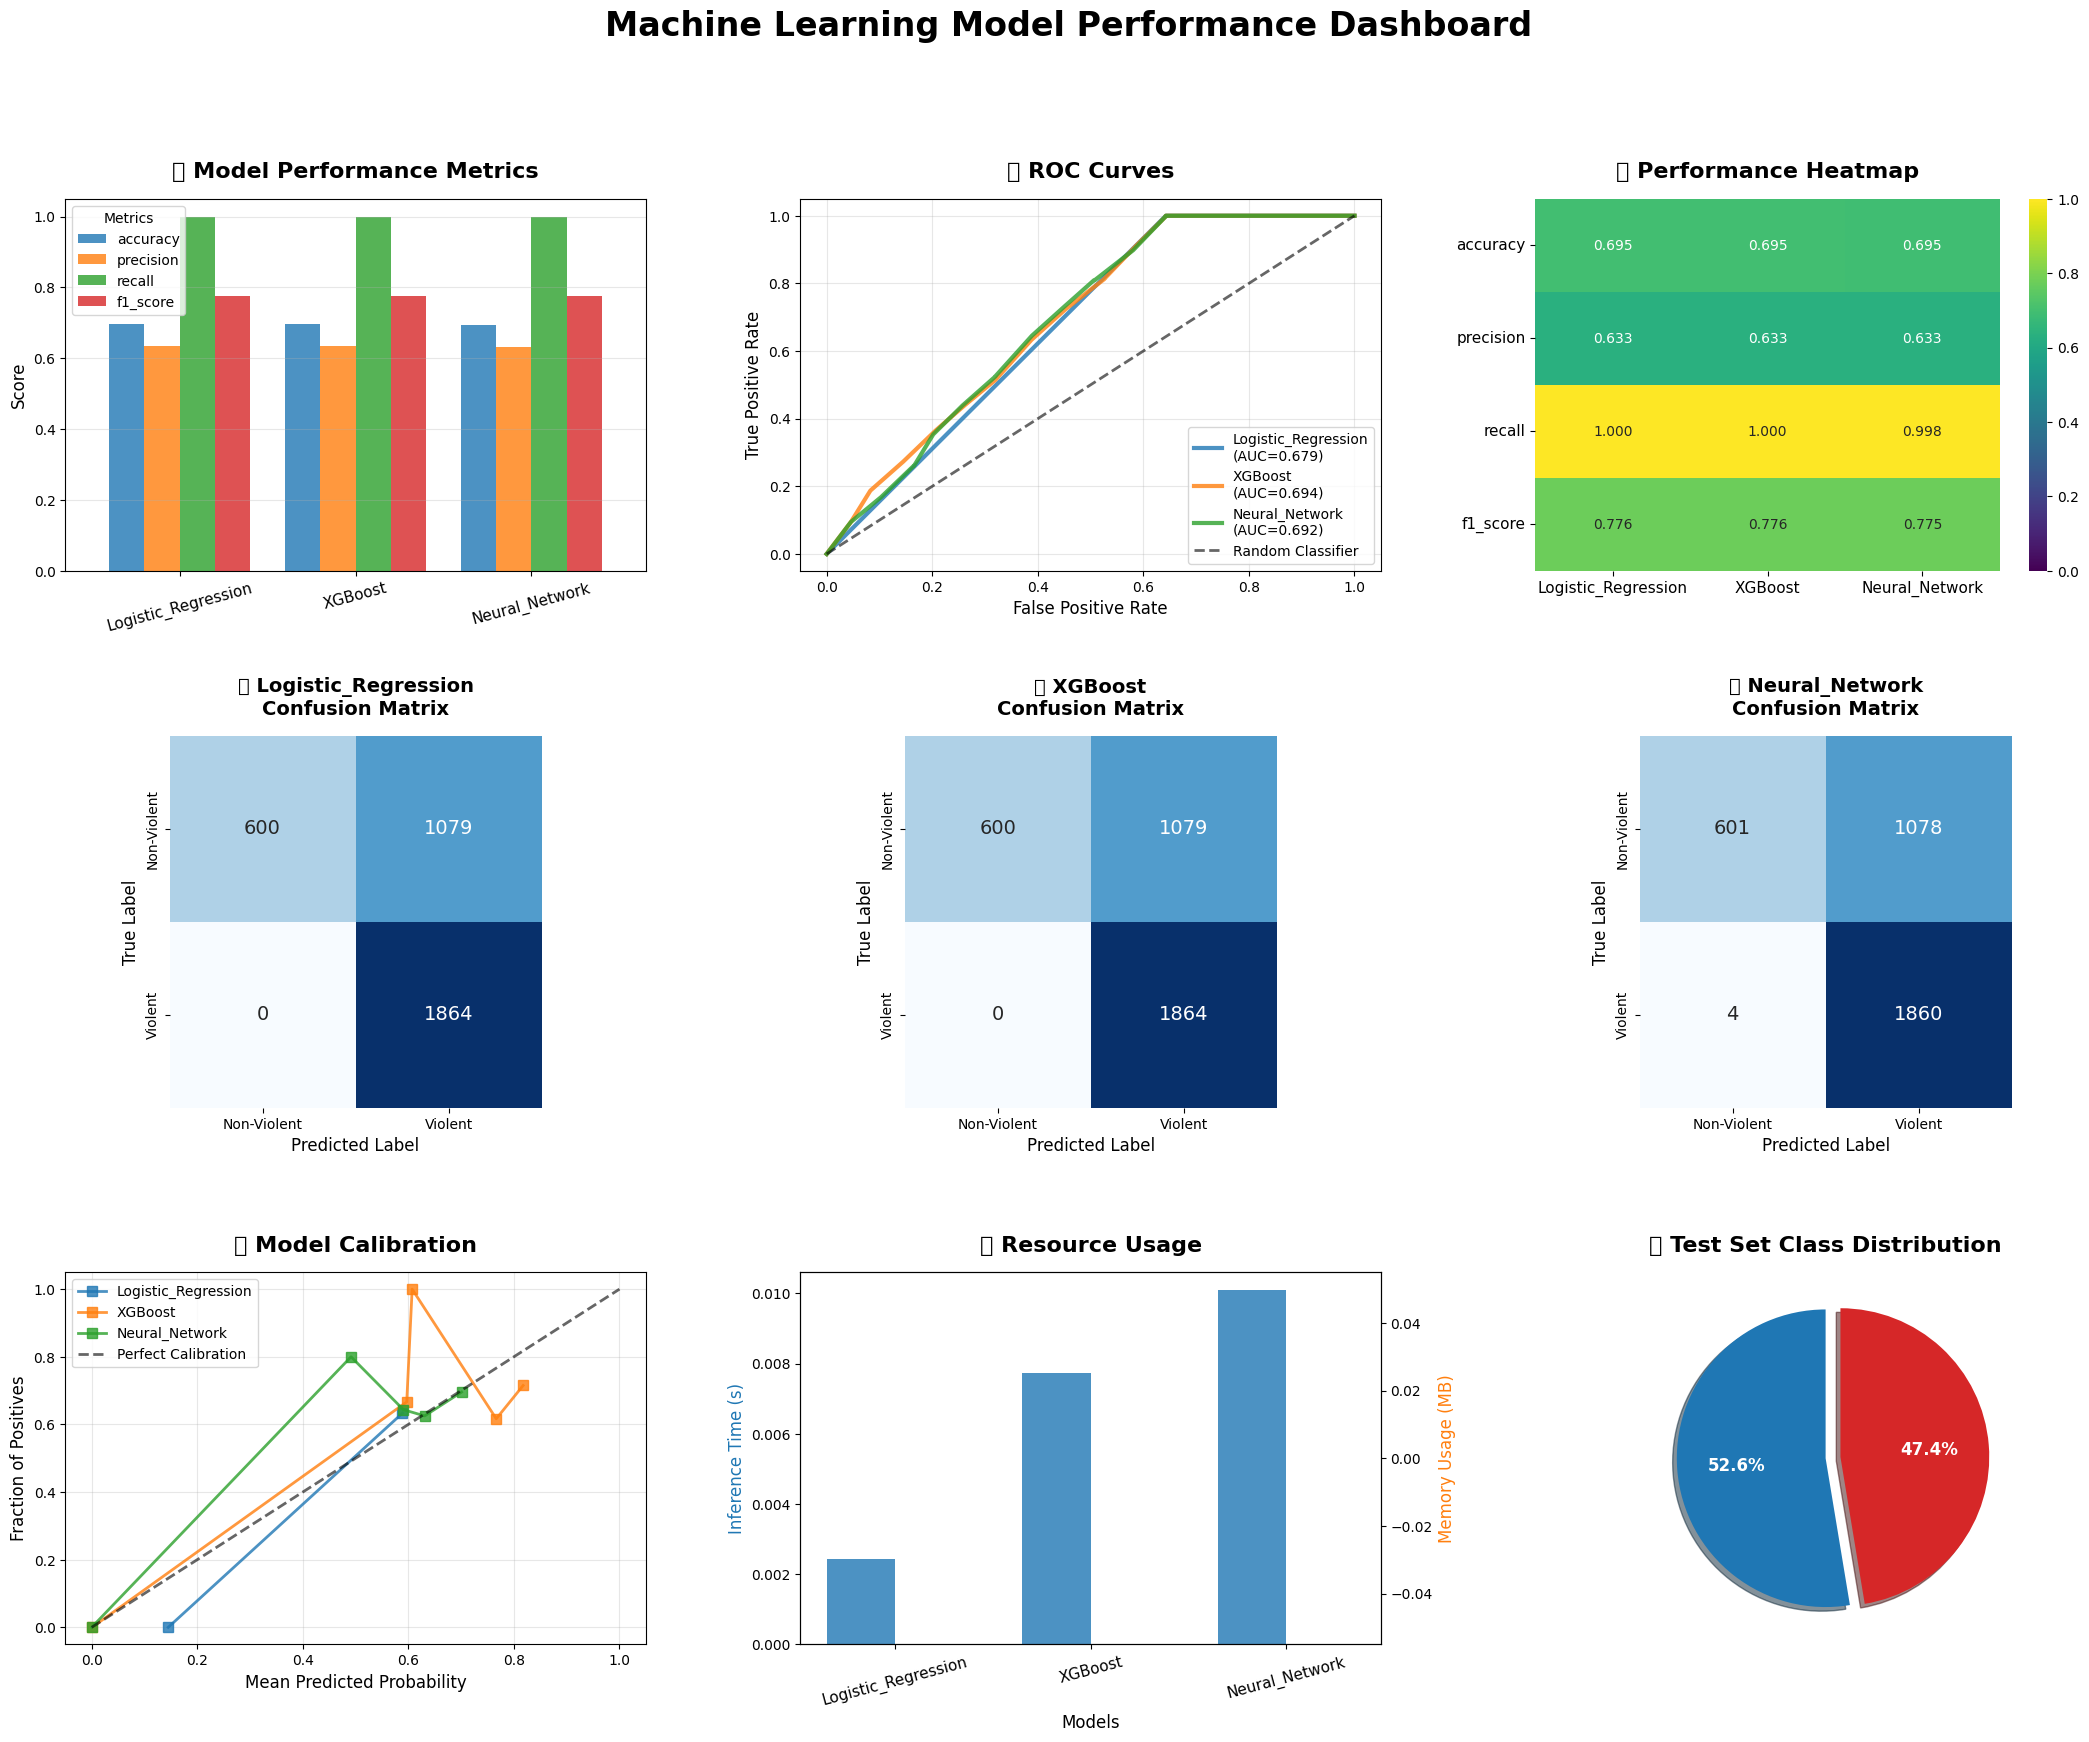

In [ ]:
# Visualization
create_performance_dashboard(
  evaluation_results_result,
  calibration_results_result,
  y_test
)



-- Generating Cross-Validation Analysis Dashboard --
------------------------------------------------------------
📊 Generating diagnostic plots for the best model: Logistic_Regression


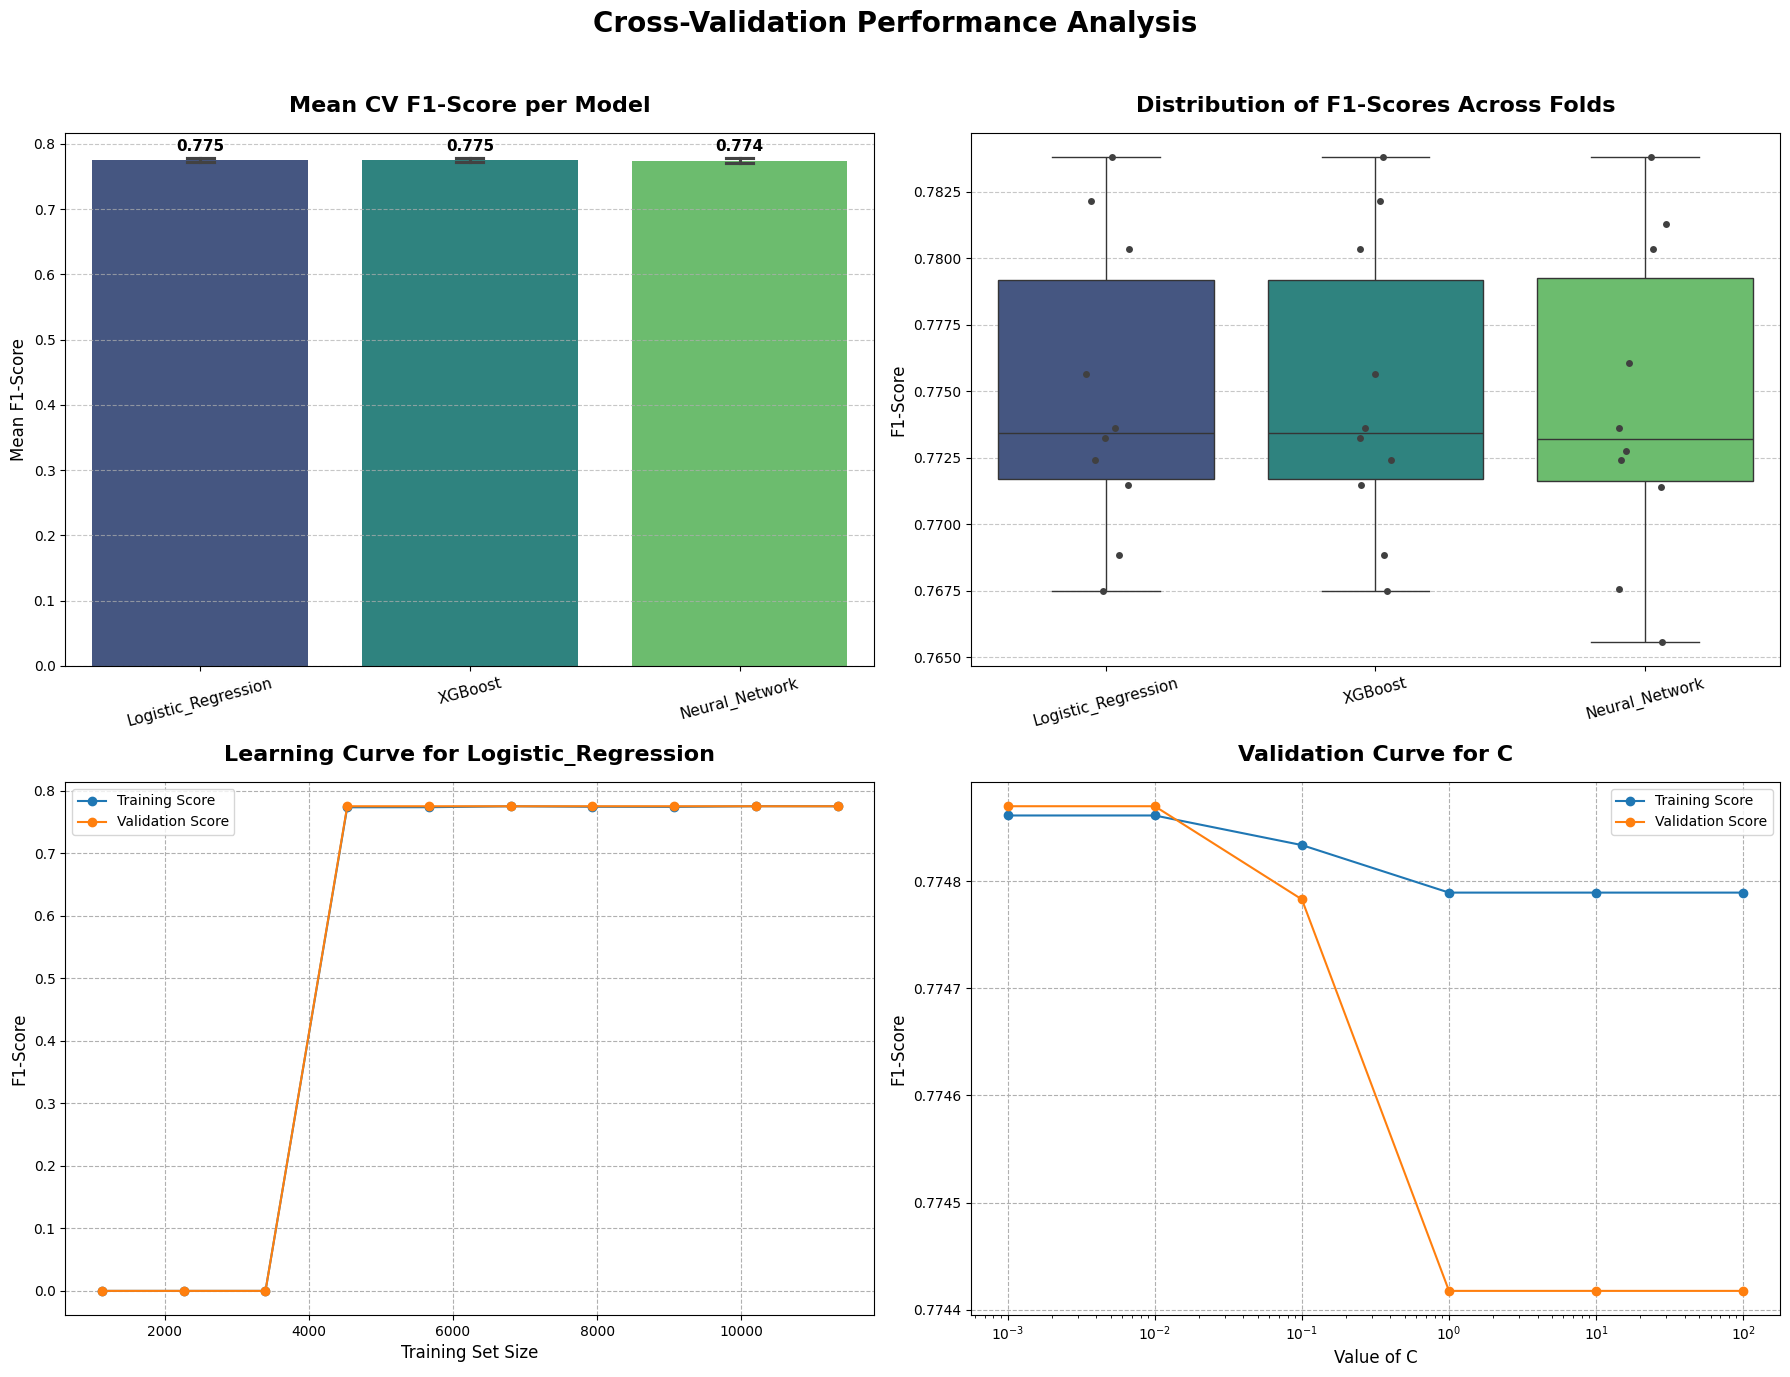

In [ ]:
create_cv_visualization(cv_results, best_models_result, X_train_scaled, y_train)

In [ ]:
create_detailed_analysis_report(
  evaluation_results_result, tuning_results_result, calibration_results_result,
  optimal_thresholds_result, fairness_results_result
 )


15. DETAILED ANALYSIS REPORT
              Model F1-Score Precision Recall ROC-AUC Inference Time
Logistic_Regression   0.7755    0.6334 1.0000  0.6787        0.0024s
            XGBoost   0.7755    0.6334 1.0000  0.6938        0.0077s
     Neural_Network   0.7747    0.6331 0.9979  0.6917        0.0101s

BEST PERFORMING MODEL: Logistic_Regression
   F1-Score: 0.7755
